In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns #used for prope graphin
from data_cleaning import preprocess_resume #.py cleaning file for preprocess_resume function

raw_df = pd.read_csv('data/AI_Resume_Screening.csv')
df = preprocess_resume(raw_df) 
df[['Resume_Text', 'Job Role']].head() #check for preprocess

,Resume_Text,Job Role
0,tensorflow nlp pytorch 10 years b sc 8 projects,AI Researcher
1,deep learning machine learning python sql 10 y...,Data Scientist
2,ethical hacking cybersecurity linux 1 years mb...,Cybersecurity Analyst
3,python pytorch tensorflow 7 years b tech aws c...,AI Researcher
4,sql react java 4 years phd 9 projects,Software Engineer


In [3]:
from sklearn.model_selection import train_test_split
#feature n target
X = df['Resume_Text']
y = df['Job Role']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, stratify= y) #here we choose 80/20 split train to test, stratify for equal num of split of vars
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")


Training samples: 800
Testing samples:  200


In [4]:
#tfidf - We r usin this to check term frequencies, common become useless and rarer words more priori
from sklearn.feature_extraction.text import TfidfVectorizer #for text freq inverse doc freq 
tfidf = TfidfVectorizer(stop_words='english') #to remove english words which are common
X_train_tfidf = tfidf.fit_transform(X_train) #fittin n transform
X_test_tfidf = tfidf.transform(X_test) #transforms test set from wht we just learned earlier essentially
print(f"TF-IDF Matrix Shape: {X_train_tfidf.shape}")
print(f"Total Unique Vocabulary Learned: {len(tfidf.get_feature_names_out())} words")

TF-IDF Matrix Shape: (800, 27)
Total Unique Vocabulary Learned: 27 words


In [6]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

naiveBayes = MultinomialNB() #model
naiveBayes.fit(X_train_tfidf, y_train) #test model using tfidf data
y_pred = naiveBayes.predict(X_test_tfidf) #this for prediction on the data tht we havent seen
#performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

Model Accuracy: 100.00%

=== Classification Report ===
                       precision    recall  f1-score   support

        AI Researcher       1.00      1.00      1.00        51
Cybersecurity Analyst       1.00      1.00      1.00        51
       Data Scientist       1.00      1.00      1.00        51
    Software Engineer       1.00      1.00      1.00        47

             accuracy                           1.00       200
            macro avg       1.00      1.00      1.00       200
         weighted avg       1.00      1.00      1.00       200



In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

logisticReg = LogisticRegression() #logisicReg model
logisticReg.fit(X_train_tfidf, y_train) 
logicRegPred = logisticReg.predict(X_test_tfidf) 
logicRegAcc = accuracy_score(y_test, logicRegPred)

svc = LinearSVC(random_state=42) #this for lin support vec machine model 
svc.fit(X_train_tfidf, y_train)
svcPred = svc.predict(X_test_tfidf)
svcAcc = accuracy_score(y_test, svcPred)

print("-- Model Comparison --")
print(f"Multinomial Naive Bayes:  {accuracy * 100:.2f}%")
print(f"Logistic Regression:      {logicRegAcc * 100:.2f}%")
print(f"Linear Support Vector:    {svcAcc * 100:.2f}%")


-- Model Comparison --
Multinomial Naive Bayes:  100.00%
Logistic Regression:      100.00%
Linear Support Vector:    100.00%


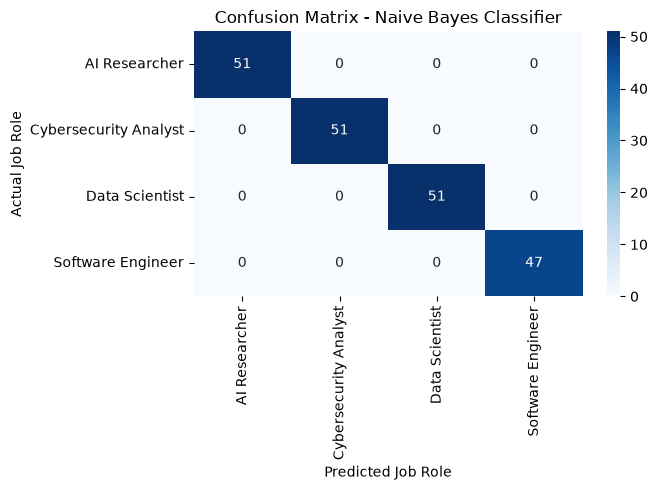

In [9]:
import seaborn as sns

confuMatrix = confusion_matrix(y_test, y_pred, labels=naiveBayes.classes_)

plt.figure(figsize=(7, 5)) #heatmap plottin
sns.heatmap(confuMatrix, annot=True, fmt='d', cmap='Blues', xticklabels=naiveBayes.classes_, yticklabels=naiveBayes.classes_)
plt.title('Confusion Matrix - Naive Bayes Classifier')
plt.xlabel('Predicted Job Role')
plt.ylabel('Actual Job Role')
plt.tight_layout()
plt.show()